Overview

Welcome to the 2026 Kaggle Playground Series! We plan to continue in the spirit of previous playgrounds, providing interesting and approachable datasets for our community to practice their machine learning skills, and anticipate a competition each month.

Your Goal: Predict the likelihood of customer churn.

## Solution Approach

This notebook follows a simple and practical workflow to solve the competition problem:

1. **Exploratory Data Analysis (EDA)**  
    Understand the dataset structure, inspect variable types, check missing values, review target distribution, and identify patterns that may be useful for prediction.

2. **Data Cleaning and Feature Engineering**  
    Handle null or inconsistent values, transform categorical variables, create or simplify features when needed, and prepare the dataset for modeling.

3. **Model Selection**  
    Start with a baseline model, then compare alternative approaches to identify a model that offers a good balance between interpretability and predictive performance.

4. **Evaluation**  
    Split the data into training and validation sets, train the model, and evaluate results using appropriate metrics for the competition.

5. **Prediction and Submission**  
    Apply the same preprocessing steps to the test set, generate predictions, and prepare the final submission file in the required Kaggle format.

The goal is to build a clear, reproducible pipeline that moves from understanding the data to producing reliable competition predictions.

# Ideas

The dataset seems to have a description of a interation with half a million customers detailing individual caracteristics like gendes, tenure, senior, payment month, the monthly and total chargers.  

First easy aprouch:

LabelEncoder every categorical data and run a simple model.

Enconder based on higher churn

Create variables for every categorical variable witht he mean/desv pad/max/min  of float variables

Create variable that measure the distance of the monthly variable of the individual and the average of his group



In [1]:
import pandas as pd
import numpy as np

from fe_v0_0_0 import preprocess_data
from ev_v0_0_0 import evaluate_model
from mdl_v0_0_0 import train_model

import sys
sys.path.append('../..')
from sand import eda

train_df = pd.read_csv('../../data/playground-series-s6e3/train.csv')

In [2]:
def yes_or_no(value):
    return 1 if str(value).strip().lower() == "yes" else 0

train_df["Churn_Binary"] = train_df["Churn"].apply(yes_or_no)

del train_df['Churn']

In [3]:
# Define the specific dates range
start_date = "2023-06-01"
end_date = "2023-09-30"

safra = []
# Generate a random date within the specified range
for i in range(train_df.shape[0]):
    safra.append(
        pd.to_datetime(
            np.random.choice(pd.date_range(start=start_date, end=end_date))
        ).strftime("%Y%m")
    )

train_df["safra"] = safra

#sandeda = eda.SandEDA(train_df, "Churn_Binary", "safra", "id")
#sandeda.report('CustomerChurn_0_0_1')

In [4]:
train_df, le = preprocess_data(train_df)

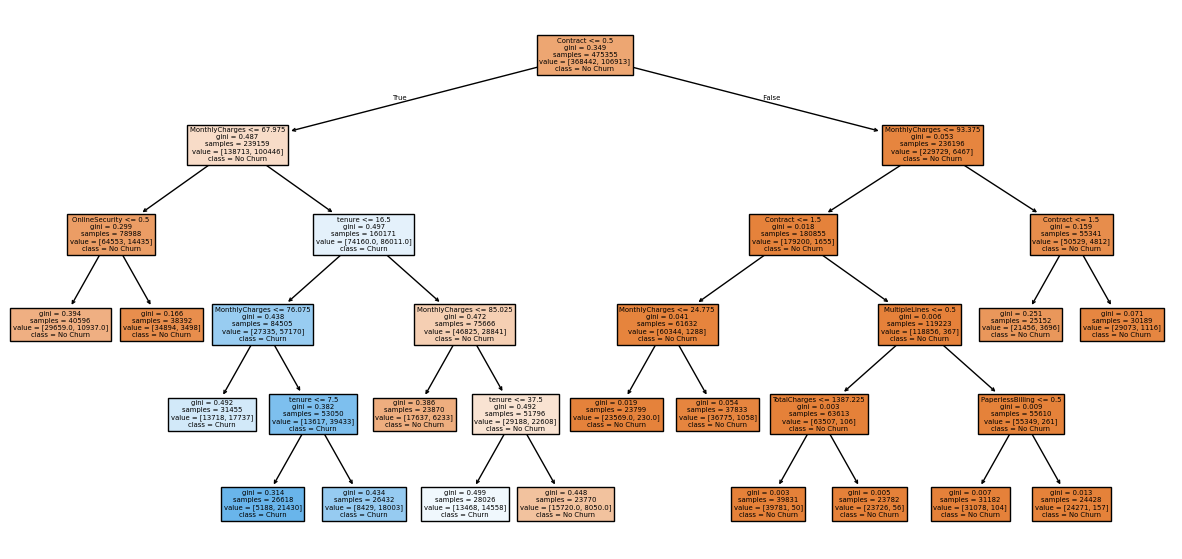

In [5]:
model, X_train, X_test, y_train, y_test = train_model(train_df, "Churn_Binary", "id", "safra")

In [ ]:
fe_version = "fe_v0_0_0"
mdl_version = "mdl_v0_0_0"
ev_version = "ev_v0_0_0"
model_name = "model_v0_0_0"

In [9]:
evaluate_model(model, 
                X_train, 
                y_train, 
                X_test, 
                y_test, 
                model_name, 
                fe_version, 
                mdl_version, 
                ev_version)

Train Metrics
ROC AUC: 0.8897

Test Metrics
ROC AUC: 0.8905

Saved model package: model_packages/model_v0_0_0_20260315_221456/model_v0_0_0.joblib
Updated registry: logs/model_registry.json
